In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    str    
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    str    
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), str(2)
memory usage: 69.5 KB


,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [4]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

cols = [
    'Children apprehended and placed in CBP custody*',
    'Children in CBP custody',
    'Children transferred out of CBP custody',
    'Children in HHS Care',
    'Children discharged from HHS Care'
]

for col in cols:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2025-12-21,6.0,18.0,11.0,2484,14.0
1,2025-12-18,11.0,50.0,6.0,2472,16.0
2,2025-12-17,7.0,31.0,11.0,2481,10.0
3,2025-12-16,8.0,54.0,15.0,2468,9.0
4,2025-12-15,11.0,42.0,9.0,2470,7.0


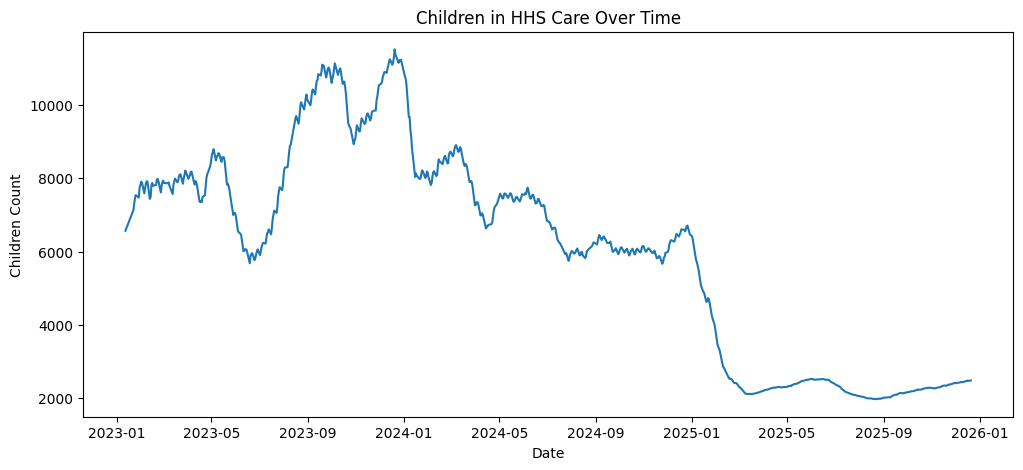

In [5]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Children in HHS Care'])
plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Children Count")
plt.show()

In [6]:
df = df.sort_values('Date')

df['day_num'] = np.arange(len(df))

X = df[['day_num']]
y = df['Children in HHS Care']

model = LinearRegression()
model.fit(X, y)

future_days = np.arange(len(df), len(df)+7).reshape(-1,1)

predictions = model.predict(future_days)

print(predictions)

[1933.57690079 1922.12697541 1910.67705003 1899.22712465 1887.77719927
 1876.32727389 1864.87734851]


c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Conclusion

This notebook performs:
- Data loading
- Data cleaning
- Data visualization
- Healthcare care load forecasting using Linear Regression

The results were used to build the Streamlit Healthcare Forecasting Dashboard.
